In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from IPython.display import display, Markdown


df = pd.read_csv('../ressourcen/Train.csv',
                 sep=',',
                 encoding='utf-8',
                 decimal='.'
                 )

print(df.head(10))
print("Rows&Cols: " ,df.shape)
values_data = df.describe()  
data_info = df.info()
unique_values = df.nunique()


print (data_info)
print(unique_values)            

duplikate = df.duplicated().sum()

print(duplikate)

display(Markdown(data_info))


   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   
5   6               F           Flight                    3                1   
6   7               D           Flight                    3                4   
7   8               F           Flight                    4                1   
8   9               A           Flight                    3                4   
9  10               B           Flight                    3                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3           

<IPython.core.display.Markdown object>

None


# Transferarbeit #
### Tim & Rodrigo ###

## Übersicht des Datensatzes: ##

### Spaltennamen, Typ & nullvalues: ###


 ```` data_info = df.info() ````
 



In [2]:
data_info = df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


Erläuterung:
- 16 Columns mit 10999 Zeilen
- 2 Daten typen String & Integer
- Wir haben keine zellen mit null values


### Anzahl eindeutiger Werte der Zeilen ###

```` unique_values = df.nunique() # Zeigt Unique Values in spalten ````

In [6]:
unique_values = df.nunique()
unique_values

ID                     10999
Warehouse_block            5
Mode_of_Shipment           3
Customer_care_calls        6
Customer_rating            5
Cost_of_the_Product      215
Prior_purchases            8
Product_importance         3
Gender                     2
Discount_offered          65
Weight_in_gms           4034
Reached.on.Time_Y.N        2
dtype: int64

Erläuterung
- Unique ID (sieht sauber aus)
- Im Datensatz sind 5 verschiedene Lager vorhanden
- Im Datensatz sind 3 verschiedene Shippingmethoden ersichtlich
- 2 Uniquewerte der Genders im Datensatz. Wahrscheindlich Male & Female
- 2 Uniquewerte für spalte Reached on Time  was auch plausibel ist 0 für "yes", 1 für "no"
- 5 Uniquewerte für Customer rating im Datensatz

### Werte in Columns mit Anzahl vorkommnissen ###

Zuerst schauen wir die Min & Max Werte an.

```` values_data = df.describe() ````


In [13]:

values_data = df.describe()
values_data

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


Werte in einzelnen Columns:


Es werden nur Columns angezeigt die weniger als 20 Unique Werte enthalten um lesbarkeit gewährleisten zu können



In [22]:
df_data_cols_values = df.drop(columns=['ID', 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms'])


for i in df_data_cols_values :
    col_vals = df_data_cols_values[i].value_counts()
    display(Markdown(f"{i}:"))
    display(col_vals)




Warehouse_block:

Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

Mode_of_Shipment:

Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

Customer_care_calls:

...

Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

Gender:

Gender
F    5545
M    5454
Name: count, dtype: int64

Reached.on.Time_Y.N:

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

## Visuelle Darstellung: Gegenüberstellung OnTime delivery zu den einzelnen Columns mit Absoluten Werten ##  

<Figure size 1800x1000 with 0 Axes>

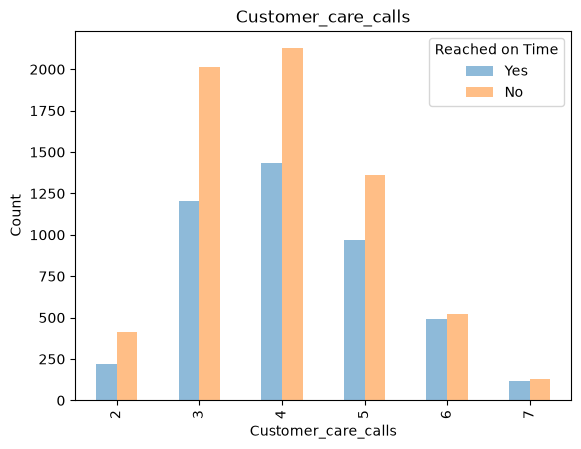

<Figure size 1800x1000 with 0 Axes>

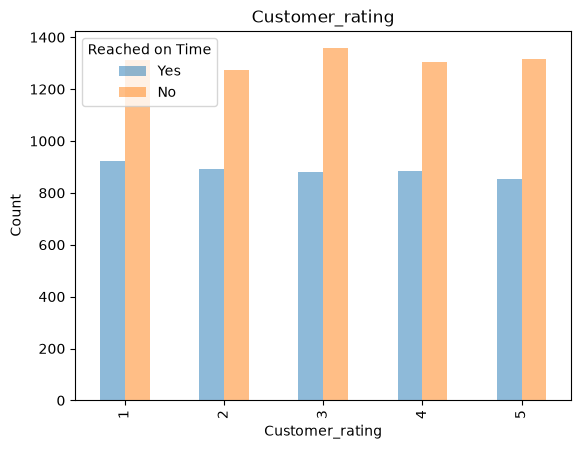

<Figure size 1800x1000 with 0 Axes>

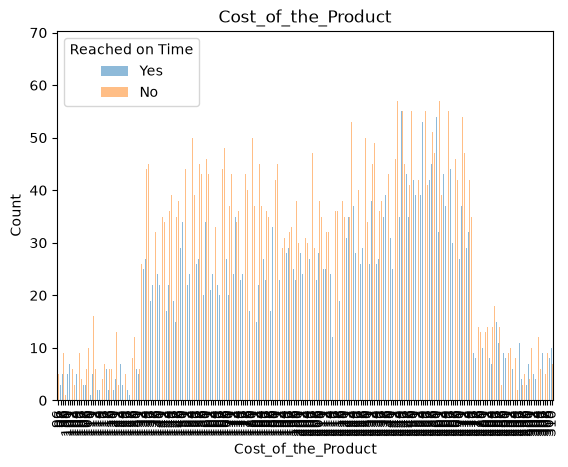

<Figure size 1800x1000 with 0 Axes>

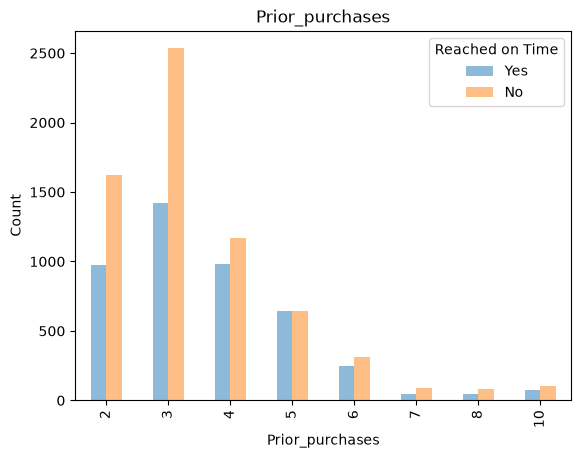

<Figure size 1800x1000 with 0 Axes>

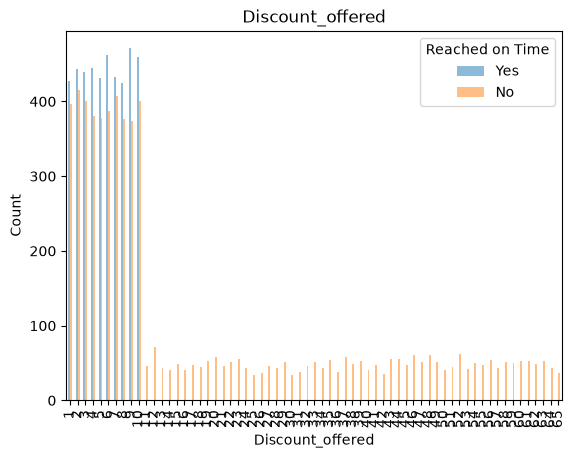

<Figure size 1800x1000 with 0 Axes>

/home/rodri/data-science/ds-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


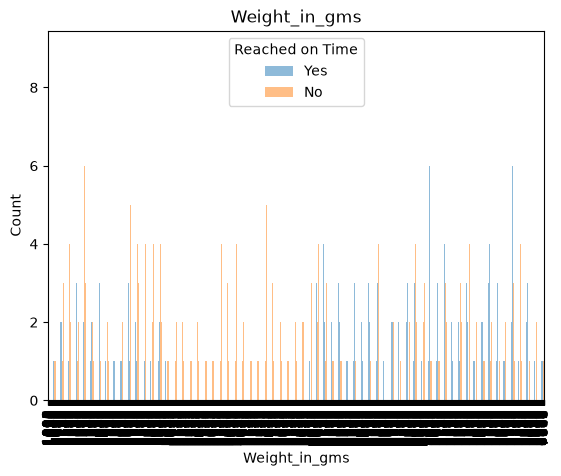

In [24]:
import matplotlib.pyplot as plt

df_data_clean = df.drop(columns=['ID'])

df_int_cols = df_data_clean.select_dtypes(include = ['int64'])

for i in df_int_cols.columns[:-1]:
    plt.figure(figsize=(18,10 ))
    ax = (
        df_int_cols.groupby(i)['Reached.on.Time_Y.N']
        .value_counts()
        .unstack(fill_value=0)
        .plot(kind='bar', alpha=0.5)
    )
    ax.legend(title='Reached on Time', labels=['Yes', 'No'])
    ax.set_ylabel('Count')
    plt.title(i)
    plt.show()





### Visualisierung: Selbe Ansicht jedoch in % ###

<Figure size 1700x1000 with 0 Axes>

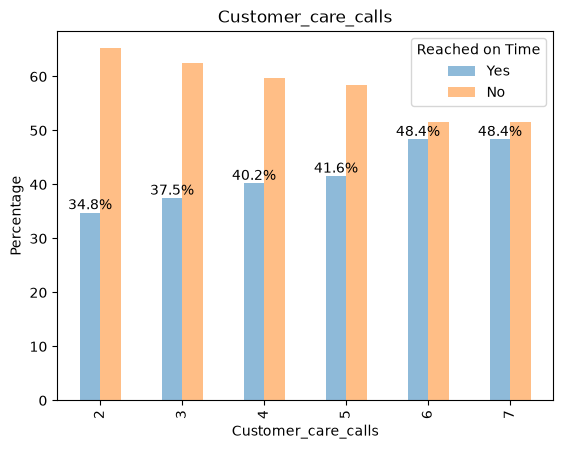

<Figure size 1700x1000 with 0 Axes>

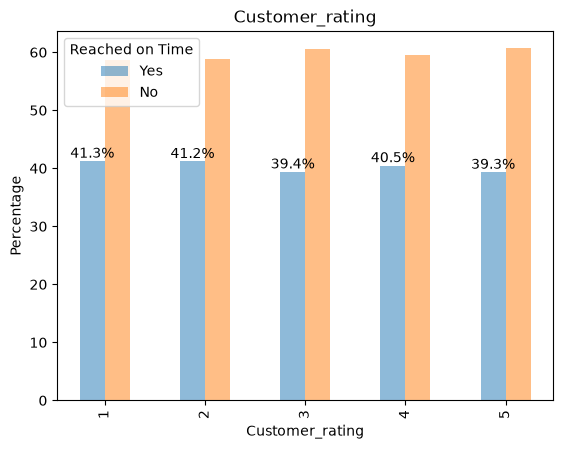

<Figure size 1700x1000 with 0 Axes>

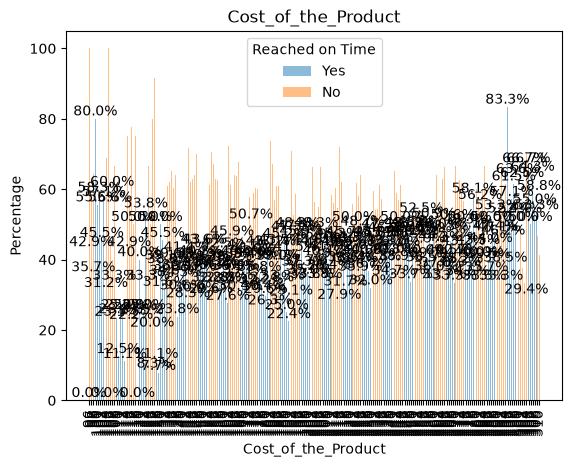

<Figure size 1700x1000 with 0 Axes>

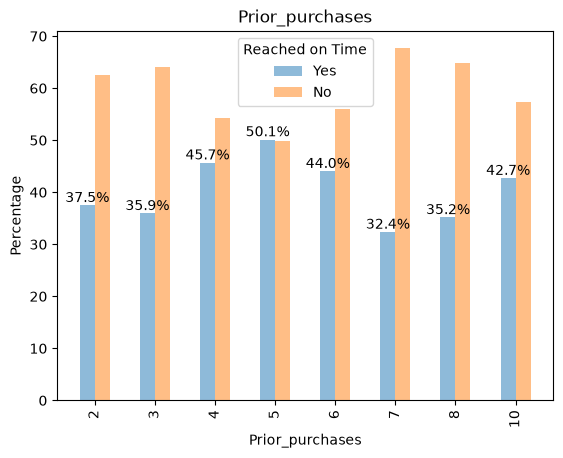

<Figure size 1700x1000 with 0 Axes>

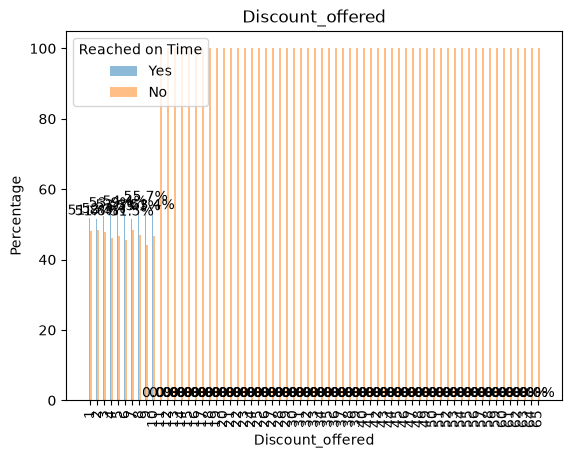

<Figure size 1700x1000 with 0 Axes>

/home/rodri/data-science/ds-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


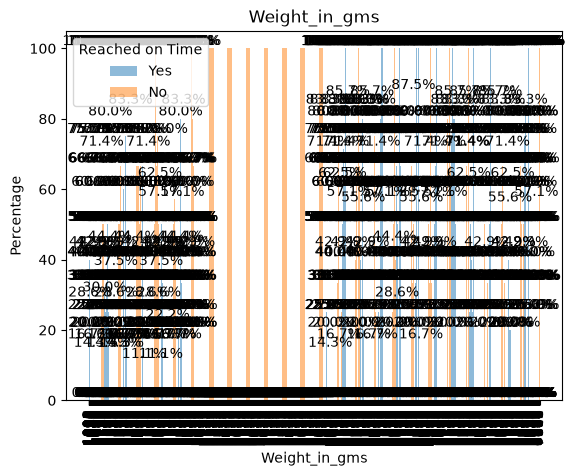

In [25]:



for i in df_int_cols.columns[:-1]:
  
    plt.figure(figsize=(17, 10))
    (
        df_int_cols.groupby(i)['Reached.on.Time_Y.N']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .mul(100)
        .plot(kind='bar', alpha=0.5)
    )
    plt.legend(title='Reached on Time', labels=['Yes', 'No'])
    plt.ylabel('Percentage')
    plt.autoscale(enable=True, axis='x')
    plt.bar_label(plt.gca().containers[0], fmt='%.1f%%', label_type='edge')
    plt.title(i)
    plt.show()

## Histogramme: Für viele Unique values


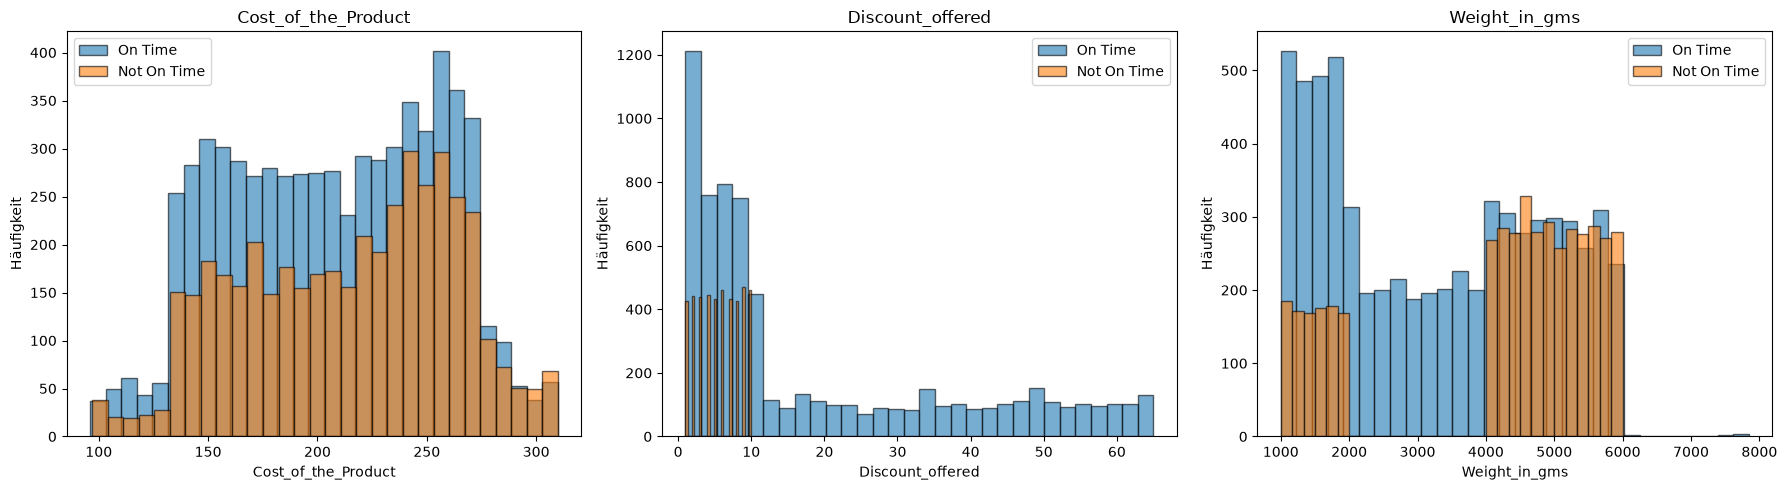

In [27]:
# Histogramme für Cost_of_the_Product, Discount_offered und Weight_in_gms
cols = ["Cost_of_the_Product", "Discount_offered", "Weight_in_gms"]

fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))

for ax, col in zip(axes, cols):
    for target, label in [(1, "On Time"), (0, "Not On Time")]:
        df[df["Reached.on.Time_Y.N"] == target][col].plot(
            kind="hist",
            bins=30,
            alpha=0.6,
            edgecolor="black",
            ax=ax,
            label=label
        )
    
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Häufigkeit")
    ax.legend()

plt.tight_layout()
plt.show()

<Axes: >

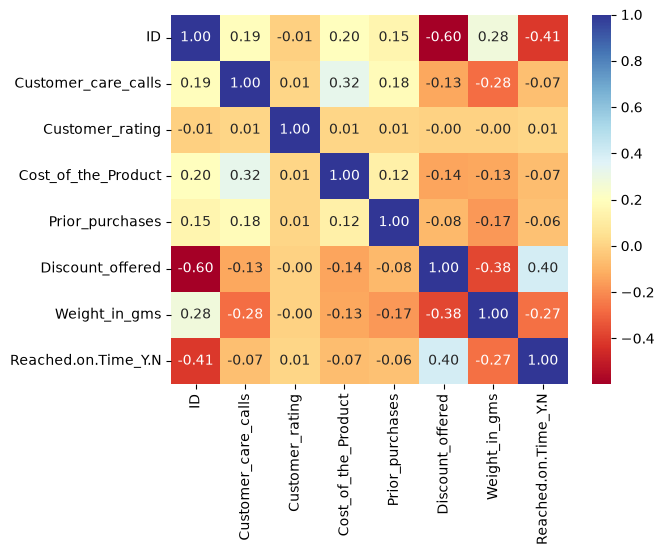

In [ ]:
import seaborn as sns
# Option 1: only numeric columns
corr = df.select_dtypes(include=["number"]).corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt=".2f")